# FAKE NEWS GROUP PROJECT: Group 54
## Preparing for the code

In [ ]:
# Importing the needed modules
import re
import nltk
import time
import numpy as np
import pandas as pd
from scipy.sparse import hstack
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.metrics import f1_score
from nltk.tokenize import RegexpTokenizer
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [12]:
# Only needed once
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bruge\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bruge\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bruge\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bruge\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Part 1 - Task 1

In [13]:
# Loading the dataset
data = pd.read_csv('fakenews_sample.csv')
data.head()

,Unnamed: 0,id,domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,keywords,meta_keywords,meta_description,tags,summary
0,0,141,awm.com,unreliable,http://awm.com/church-congregation-brings-gift...,Sometimes the power of Christmas will make you...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Church Congregation Brings Gift to Waitresses ...,Ruth Harris,NaN,[''],NaN,NaN,NaN
1,1,256,beforeitsnews.com,fake,http://beforeitsnews.com/awakening-start-here/...,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,AWAKENING OF 12 STRANDS of DNA – “Reconnecting...,Zurich Times,NaN,[''],NaN,NaN,NaN
2,2,700,cnnnext.com,unreliable,http://www.cnnnext.com/video/18526/never-hike-...,Never Hike Alone: A Friday the 13th Fan Film U...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Never Hike Alone - A Friday the 13th Fan Film ...,NaN,NaN,[''],Never Hike Alone: A Friday the 13th Fan Film ...,NaN,NaN
3,3,768,awm.com,unreliable,http://awm.com/elusive-alien-of-the-sea-caught...,"When a rare shark was caught, scientists were ...",2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Elusive ‘Alien Of The Sea ‘ Caught By Scientis...,Alexander Smith,NaN,[''],NaN,NaN,NaN
4,4,791,bipartisanreport.com,clickbait,http://bipartisanreport.com/2018/01/21/trumps-...,Donald Trump has the unnerving ability to abil...,2018-01-25 16:17:44.789555,2018-02-02 01:19:41.756632,2018-02-02 01:19:41.756664,Trump’s Genius Poll Is Complete & The Results ...,Gloria Christie,NaN,[''],NaN,NaN,NaN


In [14]:
# Function to clean the dataset
def clean_text(text):
    # Empty values
    if pd.isna(text):
        return ""
    
    # lower the text
    text = text.lower()

    # Replace url with a <URL> tag
    text = re.sub(r'https?://\S+|www\.\S+', '<URL>', text)

    # Replace emails with <EMAIL> tag
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '<EMAIL>', text)

    # Replace dates with <DATE> tag
    text = re.sub(r'[0-9]+[a-zA-Z]+', '<DATE>', text)

    # Replace all other numbers with <NUM> tag
    text = re.sub(r'[0-9]+', '<NUM>', text)
    
    # Remove any special charachters
    text = re.sub(r'[^a-zA-Z\s<>]', '', text)

    # Remove spaces, tabs and line shifts
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text # Returning the cleaned text

In [15]:
# Applying the cleaning function to the content column of the dataset
data["clean_content"] = data["content"].apply(clean_text)

# Tokenize
tokenizer = RegexpTokenizer(r'<[^>]+>|[a-zA-Z]+') # To leave tags as is
data['tokens'] = data['clean_content'].apply(tokenizer.tokenize)

# Filter tokens 
english_stopwords = set(stopwords.words('english')) # Define the english stopwords
data['filtered_tokens'] = data['tokens'].apply(lambda tokens: [word for word in tokens if word not in english_stopwords])

# Stemming
ps = PorterStemmer() # Creating a stemmer
data['stemmed'] = data['filtered_tokens'].apply(lambda x: [ps.stem(w) if not w.startswith('<') else w for w in x])

In [17]:
# Extracting all words from the tokens, filtered tokens and stemmed lists
all_words_list = [word for sublist in data['tokens'] for word in sublist]
filtered_words_list = [word for sublist in data['filtered_tokens'] for word in sublist]
all_stemmed_words = [word for sublist in data['stemmed'] for word in sublist]

# Finding unique words to create vocabularies
vocab = set(all_words_list)
vocab_filt = set(filtered_words_list)
vocab_stemmed = set(all_stemmed_words)

# Calculate lenght of the vocabularies
vocab_size = len(vocab)
filt_vocab_size = len(vocab_filt)
vocab_stemmed_size = len(vocab_stemmed)

In [ ]:
# Calculating the reduction in vocabulary size after removing stopwords
reduction_filtering = (1 - (filt_vocab_size / vocab_size)) * 100

# Calculating the reduction in vocabulary size after stemming
reduction_stemming = (1 - (vocab_stemmed_size / filt_vocab_size)) * 100

# Printing the statistics
print(f"Number of stopwords: {len(english_stopwords)}")
print(f"The first 15 english stopwords: {list(english_stopwords)[:15]}")
print("-------------------------------------")
print(f"Original Vocabulary Size: {vocab_size}")
print(f"Vocabulary Size after removing Stopwords: {filt_vocab_size} (Reduction: {reduction_filtering:.2f}%)")
print(f"Vocabulary Size after Stemming: {vocab_stemmed_size} (Reduction: {reduction_stemming:.2f}%)")

Number of stopwords: 198
The first 15 english stopwords: ['just', 'very', 'your', 'itself', 'but', "he'd", 'more', 'it', "shouldn't", 'who', 'myself', 'these', 'because', 'when', 't']
-------------------------------------
Original Vocabulary Size: 16474
Vocabulary Size after removing Stopwords: 16342 (Reduction: 0.80%)
Vocabulary Size after Stemming: 10929 (Reduction: 33.12%)


## Part 1 - Task 2

In [19]:
# Create variable for input file
input_file = "995,000_rows.csv"

# Define chunk size
chunk_size = 15000 

# Create a dataset reader
reader = pd.read_csv(input_file, chunksize=chunk_size)

# Create variable for output file
output_file = "processed_995K.csv"

# Initialize global statistics
global_vocab_initial = set()
global_vocab_filtered = set()
global_vocab_stemmed = set()

In [20]:
# Print to keep track of the loading of the dataset
print(f"Start processing of {input_file}...")
print(f"Chunk size: {chunk_size}")
print("------------------------------------------")

# Set the start time
start_time = time.time()

for i, chunk in enumerate(reader):
    chunk_start = time.time()
    
    # Apply the cleaning function
    chunk['content_cleaned'] = chunk['content'].apply(clean_text)

    # Tokenize
    chunk['tokens'] = chunk['content_cleaned'].apply(tokenizer.tokenize)
    
    # Update the original vocabulary
    for t_list in chunk['tokens']:
        global_vocab_initial.update(t_list)
    
    # Filter for stopwords
    chunk['filtered_tokens'] = chunk['tokens'].apply(lambda t: [w for w in t if w not in english_stopwords])

    # Update the filtered vocbulary
    for t_list in chunk['filtered_tokens']:
        global_vocab_filtered.update(t_list)
    
    # Stemming
    chunk['stemmed'] = chunk['filtered_tokens'].apply(lambda x: [ps.stem(w) if not w.startswith('<') else w for w in x])

    # Update the stemmed vocabulary
    for t_list in chunk['stemmed']:
        global_vocab_stemmed.update(t_list)
    
    # Save the data to the output file
    is_first = (i == 0)
    chunk.to_csv(output_file, index=False, mode='w' if is_first else 'a', header=is_first)
    
    # Calculate the status
    chunk_duration = time.time() - chunk_start
    total_elapsed = time.time() - start_time
    rows_so_far = (i + 1) * chunk_size
    
    # Print the status to keep track of process
    print(f"Chunk {i+1:3} | Rækker: {rows_so_far:7,} | Tid: {chunk_duration:5.2f}s | Total: {total_elapsed/60:5.2f} min")

Start processing of 995,000_rows.csv...
Chunk size: 15000
------------------------------------------
Chunk   1 | Rækker:  15,000 | Tid: 77.82s | Total:  1.31 min
Chunk   2 | Rækker:  30,000 | Tid: 72.29s | Total:  2.54 min
Chunk   3 | Rækker:  45,000 | Tid: 69.94s | Total:  3.72 min
Chunk   4 | Rækker:  60,000 | Tid: 74.57s | Total:  4.98 min
Chunk   5 | Rækker:  75,000 | Tid: 73.29s | Total:  6.23 min
Chunk   6 | Rækker:  90,000 | Tid: 74.94s | Total:  7.50 min
Chunk   7 | Rækker: 105,000 | Tid: 74.63s | Total:  8.76 min
Chunk   8 | Rækker: 120,000 | Tid: 74.42s | Total: 10.02 min
Chunk   9 | Rækker: 135,000 | Tid: 75.59s | Total: 11.30 min
Chunk  10 | Rækker: 150,000 | Tid: 74.92s | Total: 12.57 min
Chunk  11 | Rækker: 165,000 | Tid: 79.03s | Total: 13.91 min
Chunk  12 | Rækker: 180,000 | Tid: 76.79s | Total: 15.21 min
Chunk  13 | Rækker: 195,000 | Tid: 73.88s | Total: 16.46 min
Chunk  14 | Rækker: 210,000 | Tid: 69.57s | Total: 17.64 min
Chunk  15 | Rækker: 225,000 | Tid: 70.99s | T

In [21]:
# Find lenght of the datasets
vocab_og = len(global_vocab_initial)
vocab_filt = len(global_vocab_filtered)
vocab_stem = len(global_vocab_stemmed)

# Calculate reduction in vocabulary size
red_filt = (1 - (vocab_filt/vocab_og)) * 100
red_stem = (1 - (vocab_stem/vocab_og)) * 100

# Printing the statistics
print(f"Original Vocabulary Size: {vocab_og}")
print(f"Vocabulary Size after removing Stopwords: {vocab_filt} (Reduction: {red_filt:.2f}%)")
print(f"Vocabulary Size after Stemming: {vocab_stem} (Reduction: {red_stem:.2f}%)")

Original Vocabulary Size: 1845134
Vocabulary Size after removing Stopwords: 1844983 (Reduction: 0.01%)
Vocabulary Size after Stemming: 1577076 (Reduction: 14.53%)


## Part 1 - Task 3

In [22]:
# Read the processed datafile
df = pd.read_csv("processed_995K.csv", usecols=['title', 'type', 'domain', 'authors', 'content', 'content_cleaned', 'filtered_tokens', 'stemmed'])

# Fill out missing values of the most important columns
df['content'] = df['content'].fillna('')
df['content_cleaned'] = df['content_cleaned'].fillna('')
df['filtered_tokens'] = df['filtered_tokens'].fillna('')
df['stemmed'] = df['stemmed'].fillna('')

In [23]:
# Count URLs, dates and numbers in the dataset
url_count = df['content'].str.count(r'https?://\S+|www\.\S+').sum()
date_count = df['content'].str.count(r'[0-9]+[a-zA-Z]+').sum()
num_count = df['content'].str.count(r'[0-9]+').sum()

# Print the results
print(f"Total URLs count: {url_count:,.0f}")
print(f"Total dates count: {date_count:,.0f}")
print(f"Total number count: {num_count:,.0f}")

Total URLs count: 269,420
Total dates count: 672,041
Total number count: 10,620,633


In [24]:
# Find unique label types (column: type)
unique_labels = df['type'].unique()
print(f"Unique label types: {unique_labels}")

# Count of each label type
label_counts = df['type'].value_counts()
print("Label counts:")
print(label_counts)

Unique label types: ['political' 'fake' 'satire' 'reliable' 'conspiracy' 'unreliable' 'bias'
 'rumor' 'unknown' nan 'clickbait' 'hate' 'junksci'
 '2018-02-10 13:43:39.521661']
Label counts:
type
reliable                      218564
political                     194518
bias                          133232
fake                          104883
conspiracy                     97314
rumor                          56445
unknown                        43534
unreliable                     35332
clickbait                      27412
junksci                        14040
satire                         13160
hate                            8779
2018-02-10 13:43:39.521661         1
Name: count, dtype: int64


In [25]:
# Group the labels (type) to either news or fake news
df['Labels'] = df['type'].apply(lambda x: 'news' if x == 'reliable' else 'fake news')

# Check the two group labels
unique_labels_grouped = df['Labels'].unique()
print(f"\nUnique label types after grouping: {unique_labels_grouped}")

# Count the distribution of the two groups
grouped_labels_counts = df['Labels'].value_counts()
print("\nGrouped label counts:")
print(grouped_labels_counts)


Unique label types after grouping: ['fake news' 'news']

Grouped label counts:
Labels
fake news    776436
news         218564
Name: count, dtype: int64


In [26]:
# Find count of words and Type-Token Ratio
def calculate_text_stats(text):
    words = str(text).split()
    word_count = len(words)
    if word_count == 0:
        return 0, 0.0
    ttr = len(set(words)) / word_count
    return word_count, ttr

# Apply to the dataset
df['word_count'], df['ttr'] = zip(*df['content_cleaned'].apply(calculate_text_stats))

# Defining a news and fake news dataset
news_df = df[df['Labels'] == 'news']
fake_df = df[df['Labels'] != 'news']

# Find the average word count and ttr
news_count = news_df['word_count'].mean()
news_ttr = news_df['ttr'].mean()

fake_count = fake_df['word_count'].mean()
fake_ttr = fake_df['ttr'].mean()

# Print the results
print("Average word count:")
print(f"Fake News: {fake_count:.0f} words")
print(f"Reliable News: {news_count:.0f} words")
print("--------------------------------")
print("Average TTR:")
print(f"Fake News: {fake_ttr:.4f}")
print(f"Reliable News: {news_ttr:.4f}")

Average word count:
Fake News: 451 words
Reliable News: 491 words
--------------------------------
Average TTR:
Fake News: 0.6216
Reliable News: 0.5968


In [27]:
# Calculate the percentage of missing/anonymous authors
missing_fake = fake_df['authors'].isnull().mean() * 100
missing_real = news_df['authors'].isnull().mean() * 100

# Print the results
print(f"Percentage of articles without an author")
print(f"Fake News: {missing_fake:.1f}%")
print(f"Reliable News: {missing_real:.1f}%")

Percentage of articles without an author
Fake News: 46.4%
Reliable News: 37.8%


In [28]:
# Distribution of domains
fake_domains = fake_df['domain'].value_counts()
top_10_fake_perc = (fake_domains.head(10).sum() / fake_domains.sum()) * 100

news_domains = news_df['domain'].value_counts()
top_10_news_perc = (news_domains.head(10).sum() / news_domains.sum()) * 100

# Print the domain frequencies and the top ten domain percentage of the fake news dataset
print("Fake News domain distribution:")
print(fake_domains)
print(f"Top 10 domains creates {top_10_fake_perc:.1f}% of all fake news")

print("----------------------------------------")

print("Reliable News domain distribution:")
print(news_domains)
print(f"Top 10 domains creates {top_10_news_perc:.1f}% of all news")

Fake News domain distribution:
domain
beforeitsnews.com          91468
dailykos.com               77640
express.co.uk              55983
nationalreview.com         37377
sputniknews.com            37229
                           ...  
flashnewscorner.com            1
theamericancause.org           1
politicsinformation.com        1
amtvmedia.com                  1
newsmagazine.com               1
Name: count, Length: 603, dtype: int64
Top 10 domains creates 49.7% of all fake news
----------------------------------------
Reliable News domain distribution:
domain
nytimes.com            176144
www.reuters.com          3956
www.yahoo.com            2629
www.sfgate.com           2468
christianpost.com        2228
                        ...  
www.foxnews.com            77
www.nfl.com                76
www.theatlantic.com        74
www.buzzfeed.com           74
au.news.yahoo.com          64
Name: count, Length: 80, dtype: int64
Top 10 domains creates 89.4% of all news


In [29]:
# Count word frequencies
def get_word_counts(series, is_list_string=False):
    counter = Counter()
    for text in series:
        if is_list_string:
            text = str(text).replace('[', '').replace(']', '').replace("'", "")
            words = [w.strip() for w in text.split(',') if w.strip()]
        else:
            words = str(text).split()
        counter.update(words)
    return counter

In [30]:
# Find the word frequencies before and after preprocessing
counter_before = get_word_counts(df['content_cleaned'], is_list_string=False)
counter_after = get_word_counts(df['stemmed'], is_list_string=True)

# Find the 100 most common words 
top_before = counter_before.most_common(100)
words_before = [word for word, _ in top_before]

top_after = counter_after.most_common(100)
words_after = [word for word, _ in top_after]

# Find the frequencies for the 100 most common words
freq_before = [count for _, count in top_before]
freq_after = [count for _, count in top_after]

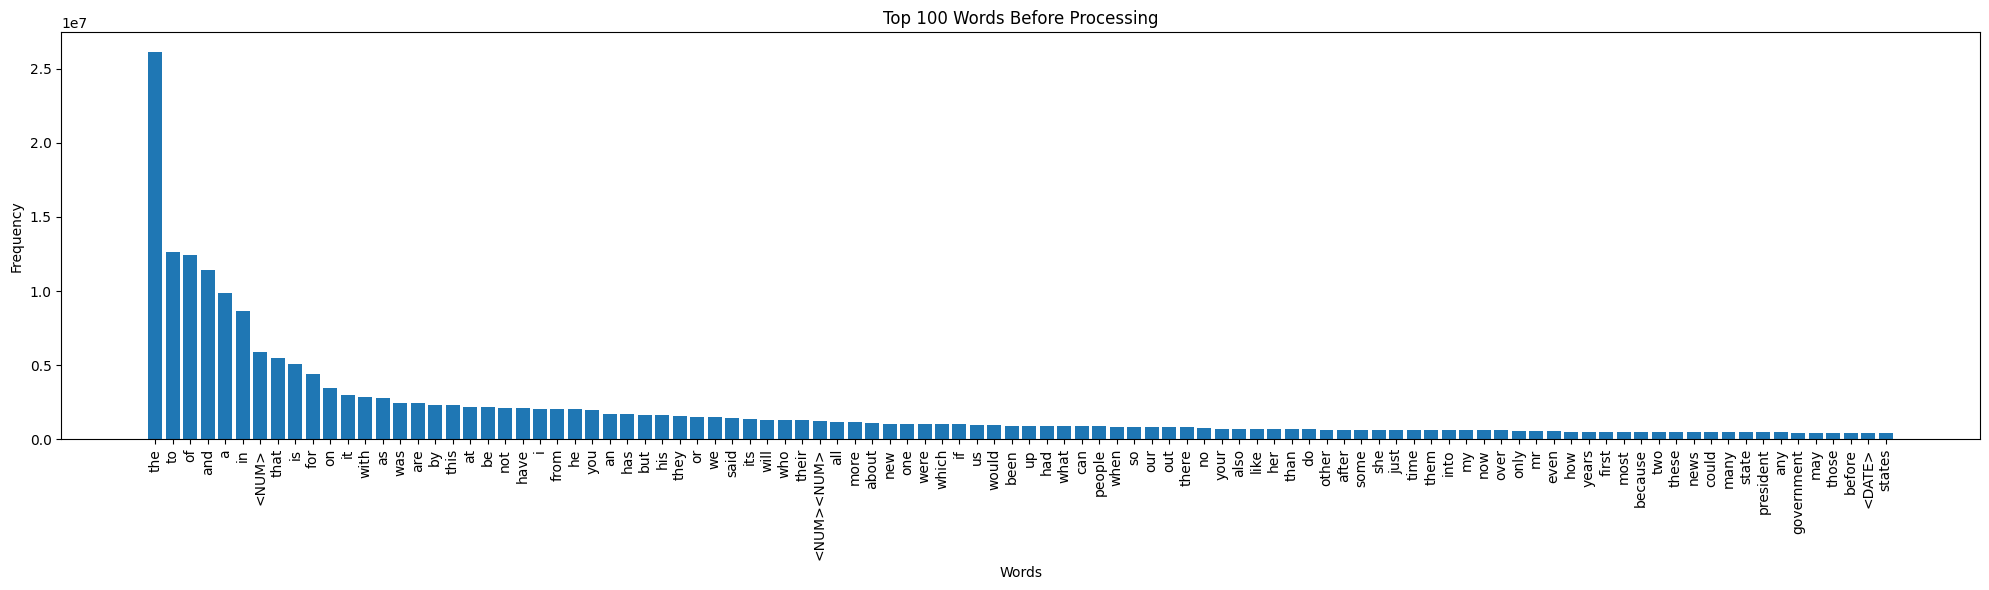

In [31]:
# Plotting the 100 most frequent words before preprocessing
plt.figure(figsize=(20, 6))
plt.bar(words_before, freq_before)
plt.xticks(rotation=90)
plt.title("Top 100 Words Before Processing")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

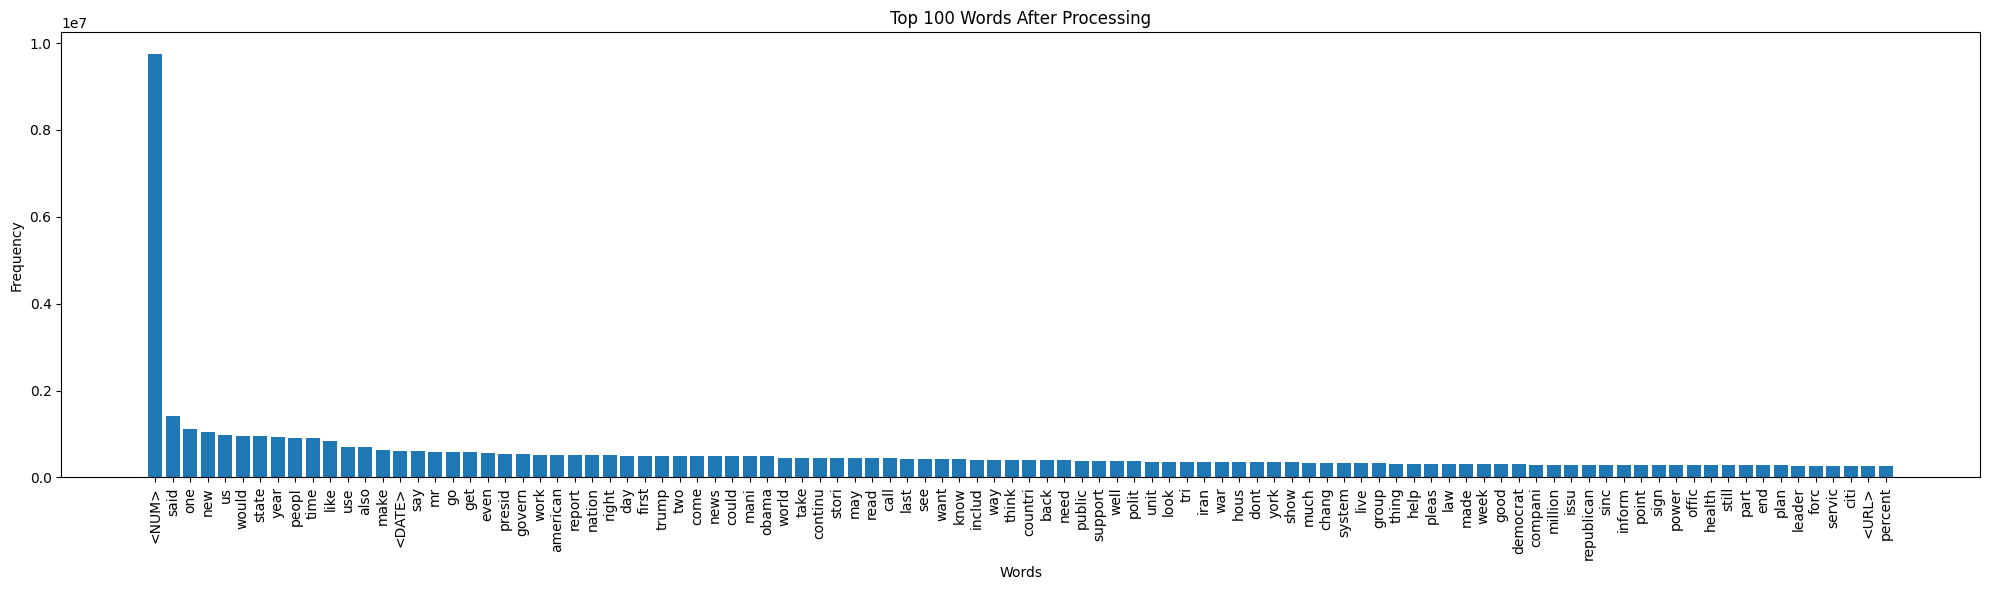

In [ ]:
# Plotting the 100 most frequent words after preprocessing
plt.figure(figsize=(20, 6))
plt.bar(words_after, freq_after)
plt.xticks(rotation=90)
plt.title("Top 100 Words After Processing")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

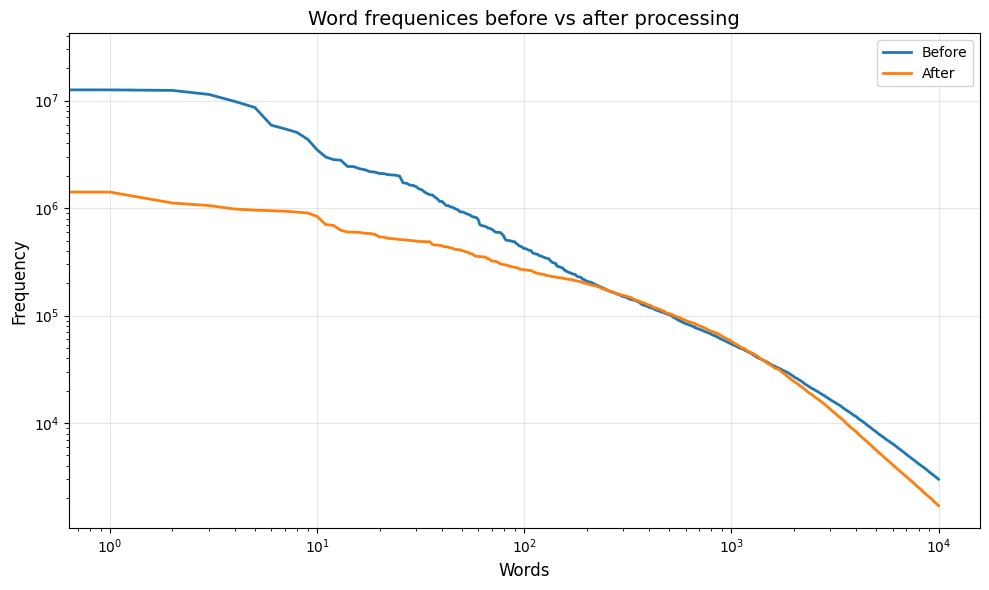

In [75]:
# Find the frequencies for the 10,000 most common words
before_freq = [count for _, count in counter_before.most_common(10000)]
after_freq = [count for _, count in counter_after.most_common(10000)]

# Plot the frequencies
plt.figure(figsize=(10, 6))
plt.plot(before_freq, label='Before', linewidth=2)
plt.plot(after_freq, label='After', linewidth=2)
plt.title("Word frequenices before vs after processing", fontsize=14)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 1 - Task 4

In [34]:
# Splitting the dataset into training (80%) and temperary splits (20%)
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)

# Splitting the temperary split into validation (10%) and test splits (10%)
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

In [35]:
# Calculate lenghts of dataset splits
train_len = len(train_df)
val_len = len(val_df)
test_len = len(test_df)

# Calculate the percentage of fake news in the dataset splits
train_perc = (train_df['Labels'] == 'fake news').mean()
val_perc = (val_df['Labels'] == 'fake news').mean()
test_perc = (test_df['Labels'] == 'fake news').mean()

# Printing the statistics
print(f"Training data (80%): {train_len} rows")
print(f"Validation data (10%): {val_len} rows")
print(f"Test data (10%): {test_len} rows")
print("-----------------------------------------")
print(f"Fake News percentage in the training data: {train_perc:.1f}%")
print(f"Fake News percentage in the validation data: {val_perc:.1f}%")
print(f"Fake News percentage in the test data: {test_perc:.1f}%")

Training data (80%): 796000 rows
Validation data (10%): 99500 rows
Test data (10%): 99500 rows
-----------------------------------------
Fake News percentage in the training data: 0.8%
Fake News percentage in the validation data: 0.8%
Fake News percentage in the test data: 0.8%


## Part 2 - Task 1
Grouping done in task 3

## Part 2 - Task 2

In [36]:
# Creating full texts of the stemmed content
train_texts = train_df['stemmed'].str.replace(r"[\[\]',]", "", regex=True)
val_texts = val_df['stemmed'].str.replace(r"[\[\]',]", "", regex=True)

# Defining label variables
y_train = train_df['Labels']
y_val = val_df['Labels']

In [37]:
# Creating vectorizer
vectorizer = CountVectorizer(max_features=10000)

# Transforming the full text
X_train = vectorizer.fit_transform(train_texts)
X_val = vectorizer.transform(val_texts)

In [76]:
# Creating the logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)

# Training the model on the trainig data
model.fit(X_train, y_train)

# Predicting on the validation data
y_pred = model.predict(X_val)

# Printing the classification report (focus on F1-score and accuracy)
print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

   fake news       0.95      0.98      0.96     77594
        news       0.92      0.81      0.86     21906

    accuracy                           0.94     99500
   macro avg       0.93      0.90      0.91     99500
weighted avg       0.94      0.94      0.94     99500



## Part 2 - Task 3

In [39]:
# Combine titel and stemmed content into one text feature
train_combined_text = train_df['title'].fillna('') + " " + train_df['stemmed'].apply(lambda x: " ".join(x))
val_combined_text = val_df['title'].fillna('') + " " + val_df['stemmed'].apply(lambda x: " ".join(x))

# Vectorize the combined text feature
X_train_text = vectorizer.fit_transform(train_combined_text)
X_val_text = vectorizer.transform(val_combined_text)

In [40]:
# Make meta-data feature
encoder = OneHotEncoder(handle_unknown='ignore')

# Transform the data
X_train_domain = encoder.fit_transform(train_df[['domain']].fillna('unknown'))
X_val_domain = encoder.transform(val_df[['domain']].fillna('unknown'))

# # Stack features together
X_train_meta = hstack([X_train_text, X_train_domain])
X_val_meta = hstack([X_val_text, X_val_domain])

In [ ]:
# Make logistic regression model for the meta-data
meta_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the meta_model on the training meta-data
meta_model.fit(X_train_meta, y_train)

# Predicting on the validation meta-data
y_pred_meta = meta_model.predict(X_val_meta)

# Printing the classification report (focus on F1-score and accuracy)
print(classification_report(y_val, y_pred_meta))

              precision    recall  f1-score   support

   fake news       1.00      1.00      1.00     77594
        news       1.00      1.00      1.00     21906

    accuracy                           1.00     99500
   macro avg       1.00      1.00      1.00     99500
weighted avg       1.00      1.00      1.00     99500



## Part 3 - Task 1

In [42]:
# Make tfidf vectorizer
tfidf = TfidfVectorizer(max_features=10000) # Use only the 10,000 most frequent words

# Transform the full text features
train_tfidf = tfidf.fit_transform(train_texts)
val_tfidf = tfidf.transform(val_texts)  

# Make encoder
encoder = LabelEncoder()

# Transform the y_train and y_val to (1, 0)
en_train = encoder.fit_transform(y_train)
en_val = encoder.transform(y_val)

In [ ]:
# Make Neural network prediction model
nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    solver='adam',
    batch_size='auto',
    early_stopping=True,
    random_state=42,
    verbose=True
)

# Train the NN model on the weighted and encoded data
nn_model.fit(train_tfidf, en_train)

Iteration 1, loss = 0.14998919
Validation score: 0.952249
Iteration 2, loss = 0.11879803
Validation score: 0.957550
Iteration 3, loss = 0.10046353
Validation score: 0.962073
Iteration 4, loss = 0.08353627
Validation score: 0.964095
Iteration 5, loss = 0.06845086
Validation score: 0.965490
Iteration 6, loss = 0.05442315
Validation score: 0.965766
Iteration 7, loss = 0.04127607
Validation score: 0.966319
Iteration 8, loss = 0.02988324
Validation score: 0.966256
Iteration 9, loss = 0.02112206
Validation score: 0.966709
Iteration 10, loss = 0.01526107
Validation score: 0.965628
Iteration 11, loss = 0.01216191
Validation score: 0.965678
Iteration 12, loss = 0.01047022
Validation score: 0.965188
Iteration 13, loss = 0.00951414
Validation score: 0.966043
Iteration 14, loss = 0.00901903
Validation score: 0.965339
Iteration 15, loss = 0.00863747
Validation score: 0.965239
Iteration 16, loss = 0.00838530
Validation score: 0.966005
Iteration 17, loss = 0.00808961
Validation score: 0.965452
Iterat

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [44]:
# Predicting on the validation data
nn_pred = nn_model.predict(val_tfidf)

# Printing the classification report (focus on F1-score and accuracy)
print(classification_report(en_val, nn_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98     77594
           1       0.94      0.91      0.92     21906

    accuracy                           0.97     99500
   macro avg       0.96      0.94      0.95     99500
weighted avg       0.97      0.97      0.97     99500



## Part 4 - Task 1

In [45]:
# Preparing the test data for the logistic regression model
test_df['Label'] = test_df['type'].apply(lambda x: 'news' if x == 'reliable' else 'fake news')
y_test = test_df['Label']

test_text = test_df['stemmed'].str.replace(r"[\[\]',]", "", regex=True)

X_test = vectorizer.transform(test_text)

In [46]:
# Predicting on the test data with the logistic regression model
test_log = model.predict(X_test)

# Printing the classification report (focus on F1-score and accuracy)
print(classification_report(y_test, test_log))

# Creating confusion matrix
test_log_cm = confusion_matrix(y_test, test_log)

# Printing the results
print("------------------------------")
print(f"TN: {test_log_cm[0][0]}, FP: {test_log_cm[0][1]}, FN: {test_log_cm[1][0]}, TP: {test_log_cm[1][1]}")

              precision    recall  f1-score   support

   fake news       0.77      0.88      0.83     77675
        news       0.16      0.08      0.10     21825

    accuracy                           0.71     99500
   macro avg       0.47      0.48      0.46     99500
weighted avg       0.64      0.71      0.67     99500

------------------------------
TN: 68675, FP: 9000, FN: 20132, TP: 1693


In [77]:
test_tfidf = tfidf.fit_transform(test_text)

# Preparing the test data for the NN model
test_labels = encoder.transform(y_test)

# Predicting on the test data with the NN model 
test_nn = nn_model.predict(test_tfidf)

# Printing the classification report (focus on F1-score and accuracy)
print(classification_report(test_labels, test_nn))

# Creating confusion matrix
test_nn_cm = confusion_matrix(test_labels, test_nn)

# Printing the results
print("------------------------------")
print(f"TN: {test_nn_cm[0][0]}, FP: {test_nn_cm[0][1]}, FN: {test_nn_cm[1][0]}, TP: {test_nn_cm[1][1]}")


              precision    recall  f1-score   support

           0       0.78      0.99      0.87     77675
           1       0.29      0.02      0.03     21825

    accuracy                           0.77     99500
   macro avg       0.53      0.50      0.45     99500
weighted avg       0.67      0.77      0.69     99500

------------------------------
TN: 76721, FP: 954, FN: 21444, TP: 381


## Part 4 - Task 2

In [48]:
# Creating column titles to fit the models input format
liar_columns = [
    'id', 'label', 'statement', 'subject', 'speaker', 'speaker_job', 
    'state_info', 'party_affiliation', 'barelytrue_counts', 'false_counts', 
    'halftrue_counts', 'mostlytrue_counts', 'pantsonfire_counts', 'context'
]

# Loading the dataset and adding the column titles
liar = pd.read_csv('test.tsv', sep='\t', names=liar_columns)

# Grouping the labels to either news or fake news
liar['new_label'] = liar['label'].apply(lambda x: 'news' if x == 'true' else 'fake news')

# Printing the first few rows of the dataset
liar.head()

,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation,barelytrue_counts,false_counts,halftrue_counts,mostlytrue_counts,pantsonfire_counts,context,new_label
0,11972.json,true,Building a wall on the U.S.-Mexico border will...,immigration,rick-perry,Governor,Texas,republican,30,30,42,23,18,Radio interview,news
1,11685.json,false,Wisconsin is on pace to double the number of l...,jobs,katrina-shankland,State representative,Wisconsin,democrat,2,1,0,0,0,a news conference,fake news
2,11096.json,false,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",donald-trump,President-Elect,New York,republican,63,114,51,37,61,comments on ABC's This Week.,fake news
3,5209.json,half-true,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",rob-cornilles,consultant,Oregon,republican,1,1,3,1,1,a radio show,fake news
4,9524.json,pants-fire,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",state-democratic-party-wisconsin,NaN,Wisconsin,democrat,5,7,2,2,7,a web video,fake news


In [49]:
# Applying cleaning function to the dataset
liar['cleaned'] = liar['statement'].apply(clean_text)

# Tokenize
liar['tokens'] = liar['cleaned'].apply(tokenizer.tokenize)

# Filter stopwords
liar['filt_tokens'] = liar['tokens'].apply(lambda tokens: [word for word in tokens if word not in english_stopwords])

# Stemming
liar['stemmed'] = liar['filt_tokens'].apply(lambda x: [ps.stem(w) if not w.startswith('<') else w for w in x])

# Full text feature
liar_text = liar['stemmed'].apply(lambda x: " ".join(x))

# Creating label variabel
y_liar = liar['new_label']

# Transforming the dataset
X_liar = vectorizer.transform(liar_text)

In [50]:
# Predicting on the LIAR dataset with the logistic regression model
liar_log = model.predict(X_liar)

# Printing the classification report (focus on F1-score and accuracy)
print(classification_report(y_liar, liar_log))

# Creating confusion matrix
liar_log_cm = confusion_matrix(y_liar, liar_log)

# Printing the results
print("------------------------------")
print(f"TN: {liar_log_cm[0][0]}, FP: {liar_log_cm[0][1]}, FN: {liar_log_cm[1][0]}, TP: {liar_log_cm[1][1]}")

              precision    recall  f1-score   support

   fake news       0.84      1.00      0.91      1059
        news       0.17      0.00      0.01       208

    accuracy                           0.83      1267
   macro avg       0.50      0.50      0.46      1267
weighted avg       0.73      0.83      0.76      1267

------------------------------
TN: 1054, FP: 5, FN: 207, TP: 1


In [51]:
# Preparing the data for the NN model
tfidf_liar = tfidf.transform(liar_text)

liar_labels = encoder.transform(y_liar)

In [52]:
# Predicting on the LIAR dataset with the NN model
liar_nn = nn_model.predict(tfidf_liar)

# Printing the classification report (focus on F1-score and accuracy)
print(classification_report(liar_labels, liar_nn))

# Creating confusion matrix
liar_nn_cm = confusion_matrix(liar_labels, liar_nn)

# Printing the results
print("------------------------------")
print(f"TN: {liar_nn_cm[0][0]}, FP: {liar_nn_cm[0][1]}, FN: {liar_nn_cm[1][0]}, TP: {liar_nn_cm[1][1]}")

              precision    recall  f1-score   support

           0       0.83      0.94      0.88      1059
           1       0.09      0.03      0.04       208

    accuracy                           0.79      1267
   macro avg       0.46      0.49      0.46      1267
weighted avg       0.71      0.79      0.75      1267

------------------------------
TN: 1000, FP: 59, FN: 202, TP: 6


## Part 5

In [78]:
# Creating function to plot confusion matrices
def plot_cm(cm, title):
    plt.figure()
    plt.imshow(cm)
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    
    plt.xticks([0,1], ['Pred Fake', 'Pred Real'])
    plt.yticks([0,1], ['Actual Fake', 'Actual Real'])
    plt.title(title)
    plt.show()

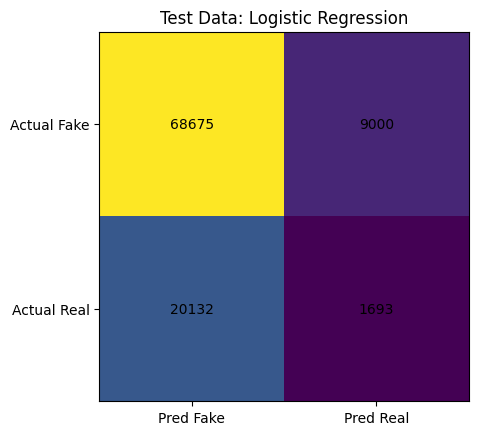

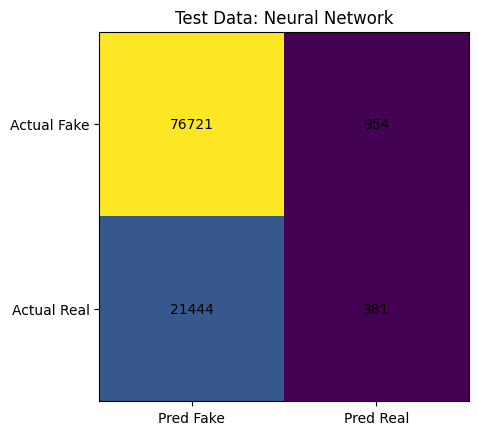

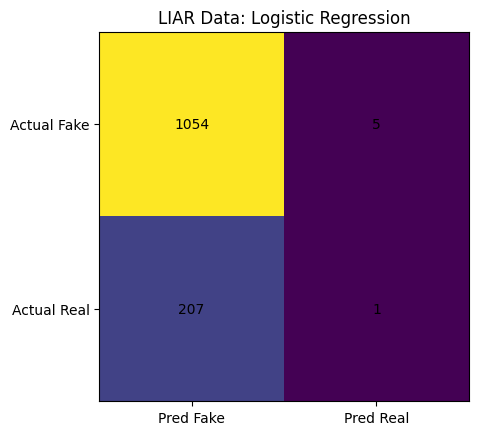

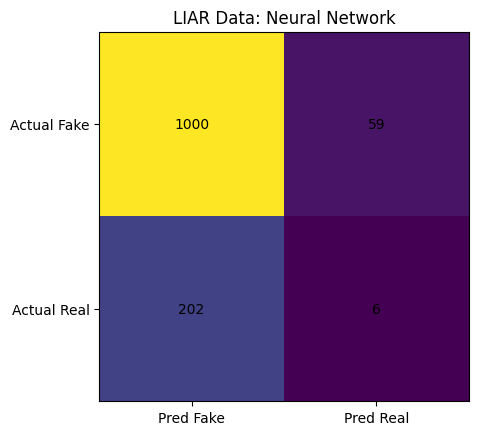

In [79]:
# Test dataset
plot_cm(test_log_cm, "Test Data: Logistic Regression")
plot_cm(test_nn_cm, "Test Data: Neural Network")

# LIAR dataset
plot_cm(liar_log_cm, "LIAR Data: Logistic Regression")
plot_cm(liar_nn_cm, "LIAR Data: Neural Network")

In [80]:
# Creating function to get the accuracy of the models
def get_accuracy(cm):
    return (cm[0][0] + cm[1][1]) / np.sum(cm)

# Logistic regression accuracies
log_acc = [get_accuracy(test_log_cm), get_accuracy(liar_log_cm)]

# Neural Network accuracies
nn_acc = [get_accuracy(test_nn_cm), get_accuracy(liar_nn_cm)]

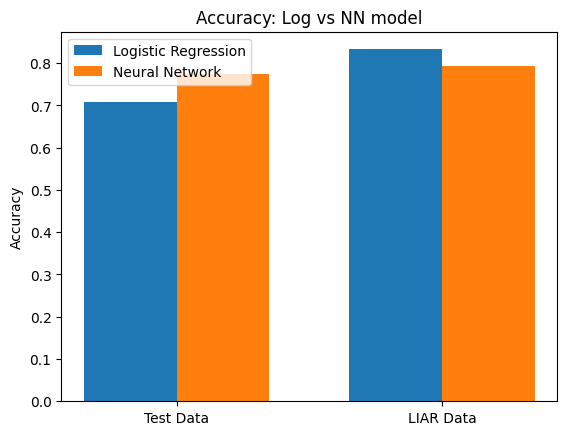

In [81]:
# Defining the dataset labels
labels = ['Test Data', 'LIAR Data']

# Defining lenghts of x and width
x = np.arange(len(labels))
width = 0.35

# Plotting the accuracies of the models on the two datasets
plt.figure()
plt.bar(x - width/2, log_acc, width, label='Logistic Regression')
plt.bar(x + width/2, nn_acc, width, label='Neural Network')
plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.title('Accuracy: Log vs NN model')
plt.legend()
plt.show()

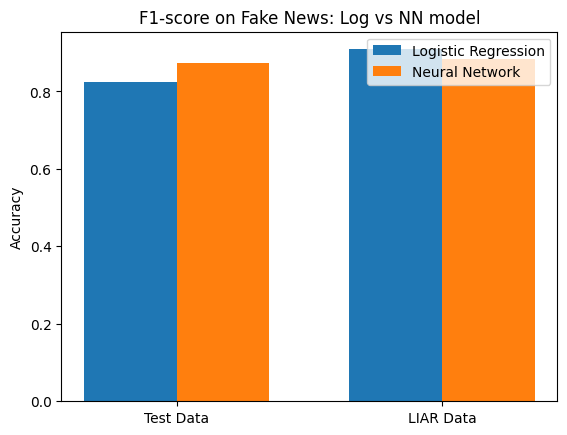

In [82]:
# Calculating F1-scores for fake news predictions
log_f1 = [f1_score(y_test, test_log, pos_label="fake news"), f1_score(y_liar, liar_log, pos_label="fake news")]
nn_f1 = [f1_score(test_labels, test_nn, pos_label = 0), f1_score(liar_labels, liar_nn, pos_label = 0)]

# Plotting the scores for each dataset
plt.figure()
plt.bar(x - width/2, log_f1, width, label='Logistic Regression')
plt.bar(x + width/2, nn_f1, width, label='Neural Network')
plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.title('F1-score on Fake News: Log vs NN model')
plt.legend()
plt.show()

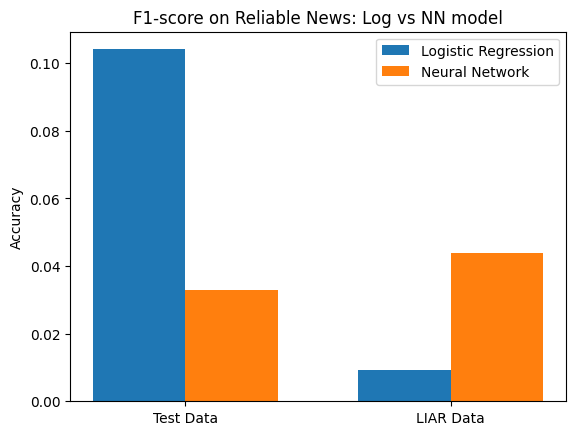

In [ ]:
# Calculating F1-scores for reliable news predictions
log_f1 = [f1_score(y_test, test_log, pos_label="news"), f1_score(y_liar, liar_log, pos_label="news")]
nn_f1 = [f1_score(test_labels, test_nn, pos_label = 1), f1_score(liar_labels, liar_nn, pos_label = 1)]

# Plotting the scores for each dataset
plt.figure()
plt.bar(x - width/2, log_f1, width, label='Logistic Regression')
plt.bar(x + width/2, nn_f1, width, label='Neural Network')
plt.xticks(x, labels)
plt.ylabel('Accuracy')
plt.title('F1-score on Reliable News: Log vs NN model')
plt.legend()
plt.show()